In [1]:
import numpy as np
import os
import astropy.units as u
import pandas as pd
from datetime import datetime, timedelta
from astropy.time import Time
import re
from sunpy.coordinates import sun
import helio_coords as hcoords

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib as mpl

import surf as surf
import surf_analysis as surfA
import surf_inputs as surfIN
import surf_insitu as surfIS

In [2]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

# Function to get earth's latitude
def get_earth_lat(dt):
    """
    A function to return Earth latitude for a given date, in radians
 
    Parameters
    ----------
    dt : datetime
 
    Returns
    -------
    E_lat: Earth latitude, with astropy units of radians
 
    """
    cr, cr_lon_init = surfIN.datetime2surfinputs(dt)
    
    # Use the HUXt ephemeris data to get Earth lat over the CR
    # ========================================================
    dummymodel = surf.SURF(v_boundary=np.ones(128)*400*(u.km/u.s), simtime=0.1*u.day,
                         cr_num=cr,cr_lon_init=cr_lon_init, lon_out=0.0*u.deg)
    # retrieve a bodies position at each model timestep:
    earth = dummymodel.get_observer('earth')
    # get average Earth lat
    E_lat = np.nanmean(earth.lat_c)
    E_lat = E_lat.to(u.deg)  # Convert to degrees
    return E_lat

def earth_R(mjd):
    #returns the heliocentric distance of Earth (in km). Based on Franz+Harper2002
    AU = 149597870.691
    
    #first up, switch to JD.
    JD=mjd+2400000.5
    d0=JD-2451545
    T0=d0/36525


    L2=100.4664568 + 35999.3728565*T0
    g2=L2-(102.9373481+0.3225654*T0)
    g2=g2*np.pi/180 #mean anomaly

    rAU=1.00014 - 0.01671*np.cos(g2)-0.00014*np.cos(2*g2);
    R=rAU*AU
    
    return R

In [3]:
def plot_huxt_multi(ax, time, model):
    """
    Plot the HUXt solution at a specified time, and (optionally) overlay the modelled flank location and field of view
    of a specified observer.
    :param ax: Axes handle to plot in.
    :param time: The time to plot. The closest value in model.time_out is selected.
    :param model: A HUXt instance with the solution in.
    :return:
    """
    id_t = np.argmin(np.abs(model.time_out - time))

    # Get plotting data
    lon_arr, dlon, nlon = surf.longitude_grid()
    lon, rad = np.meshgrid(lon_arr.value, model.r.value)
    mymap = mpl.cm.viridis
    v_sub = model.v_grid.value[id_t, :, :].copy()
    # Insert into full array
    if lon_arr.size != model.lon.size:
        v = np.zeros((model.nr, nlon)) * np.nan
        if model.lon.size != 1:
            for i, lo in enumerate(model.lon):
                id_match = np.argwhere(lon_arr == lo)[0][0]
                v[:, id_match] = v_sub[:, i]
        else:
            print('Warning: Trying to contour single radial solution will fail.')
    else:
        v = v_sub

    # Pad out to fill the full 2pi of contouring
    pad = lon[:, 0].reshape((lon.shape[0], 1)) + model.twopi
    lon = np.concatenate((lon, pad), axis=1)
    pad = rad[:, 0].reshape((rad.shape[0], 1))
    rad = np.concatenate((rad, pad), axis=1)
    pad = v[:, 0].reshape((v.shape[0], 1))
    v = np.concatenate((v, pad), axis=1)

    # Create a filled contour plot with custom over/under colours, fixed contour levels
    mymap.set_over('lightgrey')
    mymap.set_under([0, 0, 0])
    levels = np.arange(200, 800 + 10, 10)
    cnt = ax.contourf(
        lon, rad, v,
        levels=levels,
        cmap=mymap,
        extend='both')

    # Remove contour edge artefacts in vector output
    cnt.set_edgecolor("face")

    # Plot each CME’s radial profile in longitude–radius space using a rotating colour cycle; 
    # close each profile by appending the first point
    cme_colors = ['r', 'c', 'm', 'y', 'deeppink', 'darkorange']
    for j, cme in enumerate(model.cmes):
        cid = np.mod(j, len(cme_colors))
        cme_lons = cme.coords[id_t]['lon']
        cme_r = cme.coords[id_t]['r'].to(u.solRad)
        if np.any(np.isfinite(cme_r)):
            # Pad out to close the profile.
            cme_lons = np.append(cme_lons, cme_lons[0])
            cme_r = np.append(cme_r, cme_r[0])
            ax.plot(cme_lons, cme_r, '-', color=cme_colors[cid], linewidth=3)

    # Set axes customisations
    ax.set_ylim(0, model.r.value.max())
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.patch.set_facecolor('slategrey')
    return id_t

In [4]:
# Read in Met Office Cone CME files
project_dirs = surf._setup_dirs_()
crpath = os.path.join(project_dirs['input'],'(I)CMEs.csv')

# Load the CSV file into a DataFrame
crlist = pd.read_csv(crpath)

# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5', 'Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# compute 21.5-215 transit time
for irow in range(0, len(crlist)):
    crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist['tt_21'] = crlist['tt_21'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

# Add a new column with carrington rotation number of CME time
crlist['cr_num'] = crlist['Time_21.5'].apply(lambda dt: surfIN.datetime2surfinputs(dt)[0])
crlist['cr_lon_init'] = crlist['Time_21.5'].apply(lambda dt: surfIN.datetime2surfinputs(dt)[1])
crlist['earth_lat'] = crlist['Time_21.5'].apply(lambda dt: get_earth_lat(dt))

In [5]:
#HUXt run parameters
dt_scale = 4
rmin = 21.5*u.solRad
rmax = 230*u.solRad #outer boundary for HUXt runs

In [6]:
print(crlist.iloc[5,:])

Time_21.5               2023-04-21 18:12:00
Disturbance_Time        2023-04-23 17:00:00
CME_V                                  1081
lon                                      16
lat                                     -23
Ang_rad                                  39
V_max                                 711.0
V_max_smooth                        628.875
tt_21                                  1.95
cr_num                                 2270
cr_lon_init           6.028930199299501 rad
earth_lat           -5.0709161872497965 deg
Name: 5, dtype: object


In [7]:
onecme = crlist.iloc[5,:]

# Obtain MAS boundary conditions at 21.5 rS
run_start = onecme['Time_21.5']

vr_in = surfIN.get_MAS_long_profile(onecme['cr_num'], onecme['earth_lat'])
vr_MAS = surfIN.map_v_boundary_inwards(vr_in, 30*u.solRad, rmin)

# Obtain WSA boundary conditions at 21.5 rS
wsafilepath = os.path.join(os.path.join("/Users/dven/repos/Pulse_duration/surf/data/input/wsa_gong_2023042100.fits"))
v_in = surfIN.get_WSA_long_profile(wsafilepath, lat=0.0 * u.deg)
vr_WSA = surfIN.map_v_boundary_inwards(v_in, 30*u.solRad, rmin)
    
cr, cr_lon_init = surfIN.datetime2surfinputs(run_start)

HDF5 files already exist for CR2270


In [ ]:
#========================================================
# Set up the model at 21.5 rS with backmapped OMNI

five_model = surfIS.omniSURF_reconstruction(run_start, run_start +timedelta(days=27), rmin=rmin, rmax=rmax, dt_scale=4, dt=1*u.day, 
                                       run_2d=True, solver='huxt')

ten_model = surfIS.omniSURF_reconstruction(run_start, run_start +timedelta(days=27), rmin=rmin, rmax=rmax, dt_scale=4, dt=1*u.day, 
                                       run_2d=True, solver='huxt')

twenty_model = surfIS.omniSURF_reconstruction(run_start, run_start +timedelta(days=27), rmin=rmin, rmax=rmax, dt_scale=4, dt=1*u.day, 
                                       run_2d=True, solver='huxt')

sph_model = surfIS.omniSURF_reconstruction(run_start, run_start +timedelta(days=27), rmin=rmin, rmax=rmax, dt_scale=4, dt=1*u.day, 
                                       run_2d=True, solver='huxt')
    
#========================================================
# Cone cmes for 2D plot
'''Solve HUXt using a fixed pulse duration cone CME'''
    
ten_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=10.0 * 60 * 60 * u.s)

twenty_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=20.0 * 60 * 60 * u.s)

five_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=5.0 * 60 * 60 * u.s)

sph_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad,
                cme_fixed_duration=False)

# Solve for 2D plot

ten_model.solve([ten_cme])
twenty_model.solve([twenty_cme])
five_model.solve([five_cme])
sph_model.solve([sph_cme])

In [10]:
# --------------------------- OMNI ----------------------------------
bg_model = surfIS.omniSURF_reconstruction(run_start, run_start +timedelta(days=27), rmin=rmin, rmax=rmax, dt_scale=4, dt=1*u.day, 
                                       run_2d=False, solver='huxt')

OMNI_recon_model = surfIS.omniSURF_reconstruction(run_start, run_start +timedelta(days=27), rmin=rmin, rmax=rmax, dt_scale=4, dt=1*u.day, 
                                       run_2d=False, solver='huxt')

OMNI_fcst_model = surfIS.omniSURF_forecast(run_start, rmin=rmin, rmax=rmax, dt_scale=4, run_2d=False, solver='huxt')

recon_sph_model = surfIS.omniSURF_reconstruction(run_start, run_start +timedelta(days=27), rmin=rmin, rmax=rmax, dt_scale=4, dt=1*u.day, 
                                       run_2d=False, solver='huxt')

fcst_sph_model = surfIS.omniSURF_forecast(run_start, rmin=rmin, rmax=rmax, dt_scale=4, run_2d=False, solver='huxt')

fcst_bg_model = surfIS.omniSURF_forecast(run_start, rmin=rmin, rmax=rmax, dt_scale=4, run_2d=False, solver='huxt')

#========================================================
# Set up the model at 21.5 rS with backmapped MAS
    
MAS_thirty_model = surf.SURF(v_boundary = vr_MAS, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = 27.27*u.day, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

MAS_sph_model = surf.SURF(v_boundary = vr_MAS, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = 27.27*u.day, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

MAS_bg_model = surf.SURF(v_boundary = vr_MAS, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = 27.27*u.day, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

#========================================================
# Set up the model at 21.5 rS with WSA
    
WSA_six_model = surf.SURF(v_boundary = vr_WSA, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = 27.27*u.day, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

WSA_sph_model = surf.SURF(v_boundary = vr_WSA, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = 27.27*u.day, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

WSA_bg_model = surf.SURF(v_boundary = vr_WSA, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = 27.27*u.day, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

# Cone CME for time-series

OMNI_eight_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=8.5 * 60 * 60 * u.s)

OMNI_twelve_cme = surf.ConeCME(t_launch=5.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=12.2 * 60 * 60 * u.s)

MAS_thirty_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=30.4 * 60 * 60 * u.s)

WSA_six_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=6.2 * 60 * 60 * u.s)

sph_cme = surf.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad,
                cme_fixed_duration=False)

OMNI_sph_cme = surf.ConeCME(t_launch=5.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad,
                cme_fixed_duration=False)

# Solve for time_series

OMNI_recon_model.solve([OMNI_eight_cme])
OMNI_fcst_model.solve([OMNI_twelve_cme])
MAS_thirty_model.solve([MAS_thirty_cme])
WSA_six_model.solve([WSA_six_cme])

recon_sph_model.solve([sph_cme])
fcst_sph_model.solve([OMNI_sph_cme])
MAS_sph_model.solve([sph_cme])
WSA_sph_model.solve([sph_cme])

bg_model.solve([])
fcst_bg_model.solve([])
MAS_bg_model.solve([])
WSA_bg_model.solve([])

Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
removing ICME #556
removing ICME #557
removing ICME #558
removing ICME #559
removing ICME #560


Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
removing ICME #556
removing ICME #557
removing ICME #558
removing ICME #559
removing ICME #560


Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

...

removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
removing ICME #556
removing ICME #557
removing ICME #558
removing ICME #559
removing ICME #560


Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
removing ICME #556
removing ICME #557
removing ICME #558
removing ICME #559
removing ICME #560


Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
removing ICME #556
removing ICME #557
removing ICME #558
removing ICME #559
removing ICME #560


/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_26985/3466829055.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[row, col].legend(bbox_to_anchor=(0.5, -0.1), loc="center", ncol=3, frameon=False, handletextpad=0.0, columnspacing=0.0)


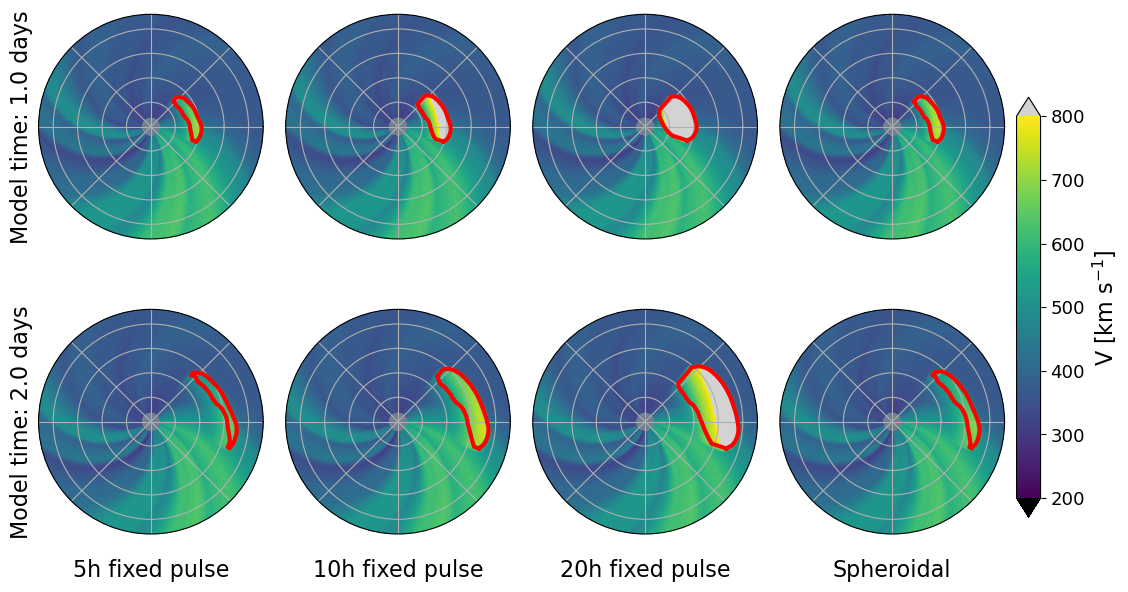

In [9]:
def plot_2D_example():
    
    # Create a 2×4 grid of polar subplots for comparing two phases at three time stamps
    fig, ax = plt.subplots(2, 4, figsize=(12, 6), subplot_kw={"projection": "polar"})

    # Define the two solar-cycle models and their labels
    models = [five_model, ten_model, twenty_model, sph_model]
    labels = ["5h fixed pulse", "10h fixed pulse", "20h fixed pulse", "Spheroidal"]

    # Loop over models and plot CME evolution for multiple times
    for col, (model, label) in enumerate(zip(models, labels)):
        cme = model.cmes[0]
        
        stats = cme.compute_arrival_at_body('Earth')
        hit_id = stats['hit_id']
        halfway_id = np.int64(np.fix(hit_id / 2.0))

        # Plot at 1, and 2 days for each model
        for row, time_out in enumerate([1.0 * u.day, 2.0 * u.day]):
            id_t = plot_huxt_multi(ax[row, col], time_out, model)

            # Add annotation showing the model time corresponding to the plotted state
            time_label = "Model time: {:3.1f} days".format(model.time_out[id_t].to(u.day).value)
            ax[row, 0].set_ylabel(time_label, fontsize=16)    
            
        # Label the left column with the model description
        ax[1, col].set_xlabel(label, fontsize=16)

    # Adjust figure spacing to fit colourbar and subplot content cleanly
    fig.subplots_adjust(left=0.075, bottom=0.12, right=0.88, top=0.99, wspace=0.1, hspace=0.3)

    # Configure colourmap and normalisation for the velocity colour scale
    mymap = mpl.cm.viridis
    mymap.set_over('lightgrey')
    mymap.set_under([0, 0, 0])
    norm = mpl.colors.Normalize(vmin=200, vmax=800)
    smp = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)

    # Add a vertical colorbar to the right of the subplot grid
    cbaxes = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(smp, cax=cbaxes, orientation='vertical', extend='both')
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('V [km s$^{-1}$]')

    # Add legends to each subplot for CME boundaries and solar-wind structures
    for row in range(2):
        for col in range(4):
            ax[row, col].legend(bbox_to_anchor=(0.5, -0.1), loc="center", ncol=3, frameon=False, handletextpad=0.0, columnspacing=0.0)

    fig.savefig("/Users/dven/repos/Pulse_duration/surf/figures/analysis/2d_pulse_example.pdf", dpi=300, bbox_inches='tight')

plot_2D_example()

Single longitude simulated. Extracting time series at Observer r
Single longitude simulated. Extracting time series at Observer r
Single longitude simulated. Extracting time series at Observer r


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Single longitude simulated. Extracting time series at Observer r
Single longitude simulated. Extracting time series at Observer r
Single longitude simulated. Extracting time series at Observer r


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

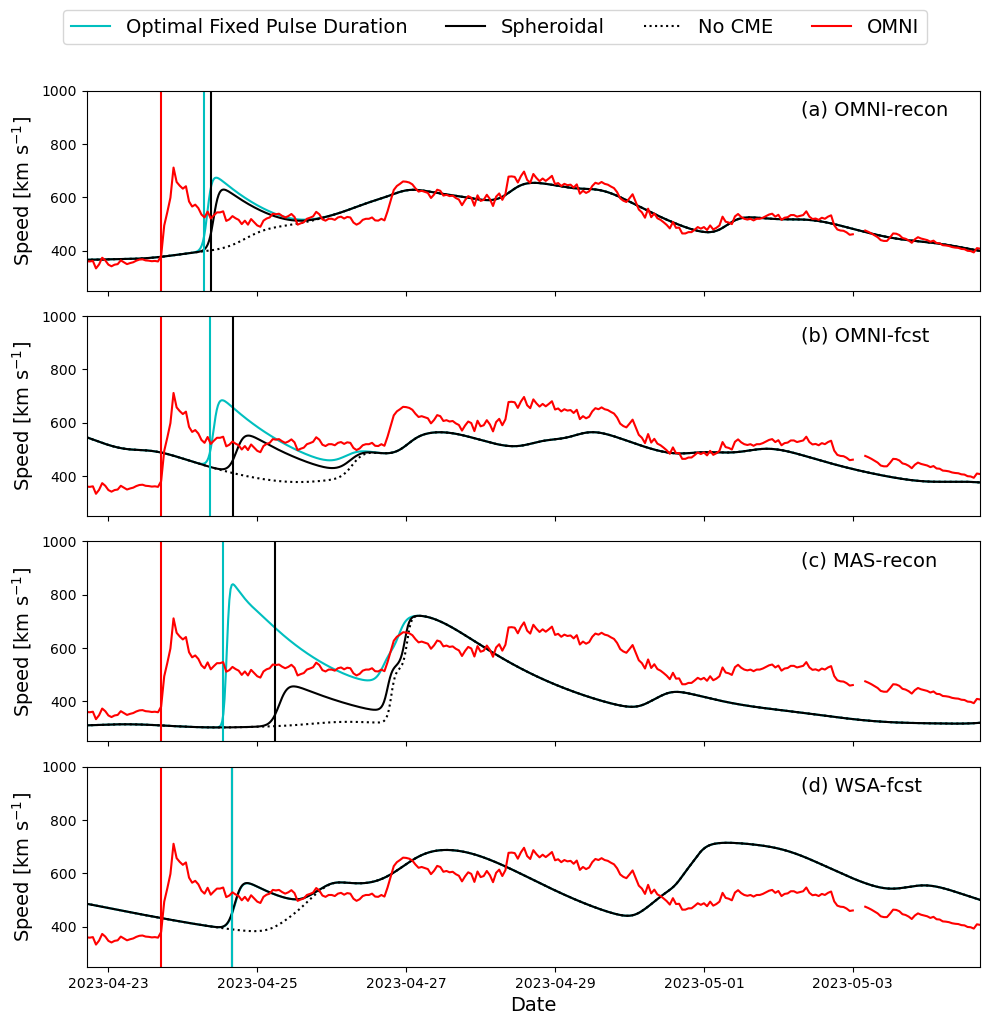

In [11]:
def plot_earth_timeseries(fixed_model, sph_model, bg_model, ax=None, plot_omni=True):
    """
    A function to plot the HUXt Earth time series. With option to download and plot OMNI data.
    Args:
        model : input model class
        plot_omni: Boolean, if True downloads and plots OMNI data

    Returns:
        fig : Figure handle
        axs : Axes handles

    """

    if ax is None:
        fig, ax = plt.subplots()
        
    fixed_ts = surfA.get_observer_timeseries(fixed_model, observer='Earth')
    sph_ts = surfA.get_observer_timeseries(sph_model, observer='Earth')
    bg_ts = surfA.get_observer_timeseries(bg_model, observer='Earth')
    
    fixed_cme_out = fixed_model.cmes[0]
    sph_cme_out = sph_model.cmes[0]
    
    fixed_stats = fixed_cme_out.compute_arrival_at_location(0.0 * u.rad, 215.0 * u.solRad)
    sph_stats = sph_cme_out.compute_arrival_at_location(0.0 * u.rad, 215.0 * u.solRad)
    
    fixed_hit = fixed_stats['hit']
    sph_hit = sph_stats['hit']
    
    if fixed_hit == 1:
        fixed_t_arrive = fixed_stats['t_arrive'].value
        sph_t_arrive = sph_stats['t_arrive'].value
        fixed_t_arrive = Time(fixed_t_arrive, format='jd', scale='utc')
        sph_t_arrive = Time(sph_t_arrive, format='jd', scale='utc')

    ax.plot(fixed_ts['time'], fixed_ts['vsw'], 'c', label='Optimal Fixed Pulse Duration')
    ax.plot(sph_ts['time'], sph_ts['vsw'], 'k', label='Spheroidal')
    ax.plot(bg_ts['time'], bg_ts['vsw'], 'k', linestyle='dotted', label='No CME')
    if  fixed_hit == 1:
        ax.axvline(sph_t_arrive.datetime,color='k')
        ax.axvline(fixed_t_arrive.datetime,color='c')
    ax.set_ylim(250, 1000)

    starttime = onecme['Disturbance_Time'] - timedelta(days=1.0)
    endtime = onecme['Disturbance_Time'] + timedelta(days=11.0)

    if plot_omni:
        # grab the omni data
        data = surfIS.get_omni(starttime, endtime)
        # plot the period of interest
        mask = (data['datetime'] >= starttime) & (data['datetime'] <= endtime)
        plotdata = data[mask]
        ax.plot(plotdata['datetime'], plotdata['V'], 'r', label='OMNI')

    ax.set_xlim(starttime, endtime)

    ax.set_ylabel(r'Speed [km s$^{-1}$]',fontsize=14)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    return ax

def plot_time_series():

    fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True, sharey=True)

    plot_earth_timeseries(OMNI_recon_model, recon_sph_model, bg_model, ax=axs[0], plot_omni=True)
    axs[0].axvline(onecme['Disturbance_Time'], color='r')

    plot_earth_timeseries(OMNI_fcst_model, fcst_sph_model, fcst_bg_model, ax=axs[1], plot_omni=True)
    axs[1].axvline(onecme['Disturbance_Time'], color='r')

    plot_earth_timeseries(MAS_thirty_model, MAS_sph_model, MAS_bg_model, ax=axs[2], plot_omni=True)
    axs[2].axvline(onecme['Disturbance_Time'], color='r')

    plot_earth_timeseries(WSA_six_model, WSA_sph_model, WSA_bg_model, ax=axs[3], plot_omni=True)
    axs[3].axvline(onecme['Disturbance_Time'], color='r')
    axs[3].set_xlabel('Date',fontsize=14)

    # ---- panel labels ----
    labels = ["(a) OMNI-recon", "(b) OMNI-fcst", "(c) MAS-recon", "(d) WSA-fcst"]
    for ax, lab in zip(axs, labels):
        ax.text(0.80, 0.95, lab,
                transform=ax.transAxes,
                fontsize=14,
                va='top')

    # Get all handles/labels from first axis
    handles, labels = axs[0].get_legend_handles_labels()

    # Shared legend at top
    fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5, 1.03),ncol=4,fontsize=14,frameon=True)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    fig.savefig("/Users/dven/repos/Pulse_duration/surf/figures/analysis/time_series_pulse_example.pdf", dpi=300,bbox_inches='tight')

plot_time_series()

Mean absolute error for OMNI-recon: 17.473163830976926
Mean absolute error for OMNI-fcst: 68.21927487443867
Mean absolute error for MAS: 75.18404191918601
Mean absolute error for WSA: 124.63939056417819


/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_43797/1798415685.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


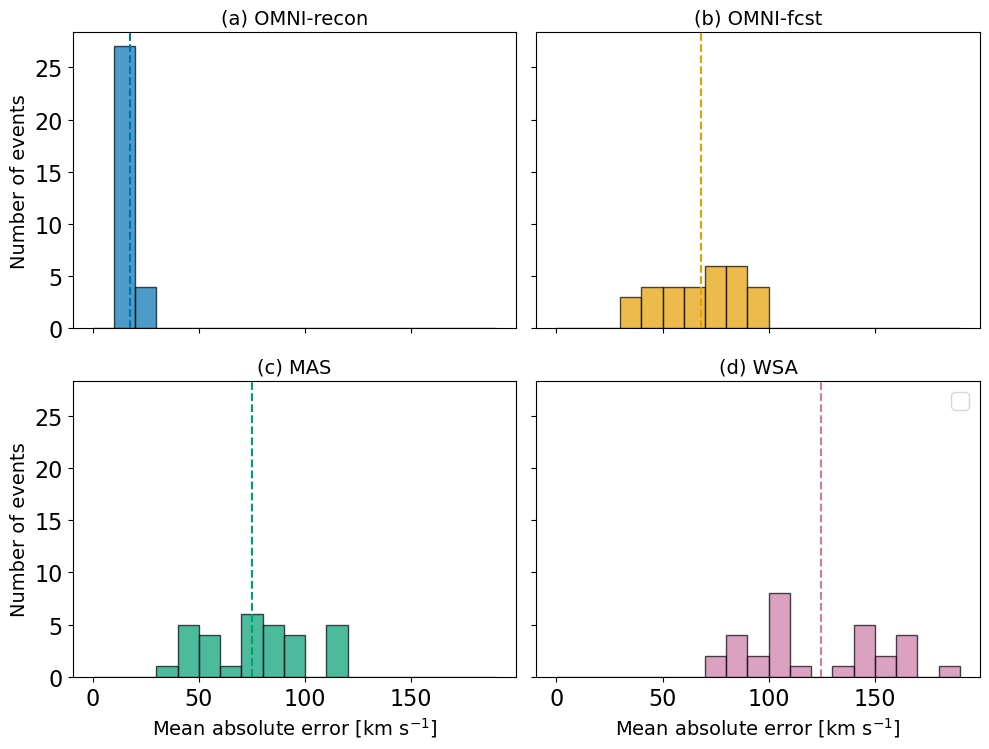

In [8]:
def mae():

    """ Plot absolute background solar wind speed errors at Earth for different background winds"""

    mae_df = pd.read_csv('/Users/dven/repos/Pulse_duration/surf/data/input/MAE_bg_wind.csv')

    # calculate absolute error means
    recon_omni = mae_df.iloc[:, 2]
    mean_recon_omni = recon_omni.mean()

    omni = mae_df.iloc[:, 1]
    mean_omni = omni.mean()

    mas = mae_df.iloc[:, 3]
    mean_mas = mas.mean()

    wsa = mae_df.iloc[:, 4]
    mean_wsa = wsa.mean()   

    fig, ax = plt.subplots(2,2,figsize=(10, 8), sharey=True, sharex=True)

    # define colours
    c_omni_recon = "#0072B2"
    c_omni_fcst = "#E69F00"
    c_mas  = "#009E73"
    c_wsa  = "#CC79A7" 

    # histograms

    ax[0,0].hist(recon_omni, alpha=0.7, color=c_omni_recon, edgecolor='black', bins=np.arange(0,200,10))
    ax[0,1].hist(omni, alpha=0.7, color=c_omni_fcst, edgecolor='black', bins=np.arange(0,200,10))
    ax[1,0].hist(mas, alpha=0.7, color=c_mas, edgecolor='black', bins=np.arange(0,200,10))
    ax[1,1].hist(wsa, alpha=0.7, color=c_wsa, edgecolor='black', bins=np.arange(0,200,10))

    # means (same colours)
    ax[0,0].axvline(mean_recon_omni, color=c_omni_recon, linestyle='--')
    ax[0,1].axvline(mean_omni, color=c_omni_fcst, linestyle='--')
    ax[1,0].axvline(mean_mas, color=c_mas, linestyle='--')
    ax[1,1].axvline(mean_wsa, color=c_wsa, linestyle='--')

    # labels and titles
    ax[1,0].set_xlabel(r'Mean absolute error [km s$^{-1}$]', fontsize=14)
    ax[1,1].set_xlabel(r'Mean absolute error [km s$^{-1}$]', fontsize=14)
    ax[0,0].set_ylabel("Number of events", fontsize=14)
    ax[1,0].set_ylabel("Number of events", fontsize=14)

    ax[0, 0].set_title('(a) OMNI-recon', fontsize=14)
    ax[0, 1].set_title('(b) OMNI-fcst', fontsize=14)
    ax[1, 0].set_title('(c) MAS', fontsize=14)
    ax[1, 1].set_title('(d) WSA', fontsize=14)

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    print('Mean absolute error for OMNI-recon:', mean_recon_omni)
    print('Mean absolute error for OMNI-fcst:', mean_omni)
    print('Mean absolute error for MAS:', mean_mas)
    print('Mean absolute error for WSA:', mean_wsa)

    plt.legend()
    plt.savefig("/Users/dven/repos/Pulse_duration/surf/figures/analysis/mae_bg_wind.pdf", format="pdf", bbox_inches="tight")

mae()